# APPA-REAL database



Prior to running one needs to set path to APPA-REAL database.

In [1]:
ROOT_FOLDER="/home/xfrancv/Data/Faces/APPA-REAL/"

Machine predictions of the real age and the apparent age on the test images of APPA-REAL are specified in CSV files: 

In [2]:
MACHINE_PREDICTION_REAL_AGE_FILE = "machine_predictions/exp006_appa-real-prediction.csv"
MACHINE_PREDICTION_APPARENT_AGE_FILE = "machine_predictions/exp008_chalearn2016-prediction.csv"

## Helper functions

In [3]:
import matplotlib.pyplot as plt
import csv 
import numpy as np

fontsize=20
def read_appareal_csv(subset):
    '''It reads given subsets (eg. ['train','valid','test']) of the APPA-REAL database.
    
    Each item describes real age (real_age) of depicted person, human prediction 
    of the age of the depicted person (apparent_age), age (worker_age) and 
    gender (worker_gender) of the idvidual guessing the age.
    '''
    
    if not isinstance(subset,list):
        subset = [subset]

    all_data=None
    for subset in subset:

        file_path = ROOT_FOLDER+"gt_" + subset + ".csv"

        with open(file_path, 'r') as csv_file:
            reader = csv.reader(csv_file)
            # Assuming the first row contains the header
            header = next(reader)

            data = {item: [] for item in header}        
            for row in reader:
                for i, item in enumerate(header):
                    data[item].append( row[i] )

        data['real_age'] = np.array( data['real_age'], dtype=int) # ground truth
        data['apparent_age'] = np.array( data['apparent_age'], dtype=int) # guessed by the worker
        data['worker_age'] = np.array( data['worker_age'], dtype=int) #

        gender_mapping = {'male': 'm', 'female': 'f', '': np.nan}
        data['worker_gender'] = np.array( [gender_mapping[gender] for gender in data['worker_gender']] )

        if all_data is None:
            all_data = data
        else:
            for key in all_data.keys():
                all_data[key] = np.append(all_data[key],data[key])

    return header, all_data

def read_machine_prediction(apparent=False):
    '''It reads predictions by a computer model on the test subset of APPA-REAL/ChaLearn
    images. The model is either trained on the ChaLearn database containing the apparent
    age or APPA-REAL database containing the true age labels, while both databases
    share the same images.

    Each item describes the real age (age), the age predicted by the model (age_pred)
    and an estimate of the prediction risk (age_risk).
    '''

    if apparent==False:
        file_path = MACHINE_PREDICTION_REAL_AGE_FILE
    else:
        file_path = MACHINE_PREDICTION_APPARENT_AGE_FILE

    with open(file_path, 'r') as csv_file:
        reader = csv.reader(csv_file)
        # Assuming the first row contains the header
        header = next(reader)

        data = {item: [] for item in header}        
        for row in reader:
            for i, item in enumerate(header):
                data[item].append( row[i] )

    data['age'] = np.array( data['age'], dtype=int)
    data['age_pred'] = np.array( data['age_pred'], dtype=int)
    data['age_risk'] = np.array( data['age_risk'], dtype=float)

    keys = ['top_left_col','top_left_row','top_right_col','top_right_row',
            'bot_right_col','bot_right_row','bot_left_col','bot_left_row']
    data['bbox'] = []
    for i in range(len(data['top_left_col'])):
        data['bbox'].append( np.array([int(data[key][i]) for key in keys]).reshape(4,2) )

    return data


def compute_errors(true_age,predicted_age,age_range=None):
    '''Given real and predicted age, it computes MAE, BIAS over all images 
    and the same for faces with agiven real age.
    '''

    if age_range is not None:
        true_ages = range(age_range[0],age_range[1]+1)
    else:
        true_ages = range(0,100)
    mae = np.full(len(true_ages),np.nan)
    bias = np.full(len(true_ages),np.nan)
    mae_low = np.full(len(true_ages),np.nan)
    mae_high = np.full(len(true_ages),np.nan)
    count = np.zeros(len(true_ages))

    for i, age in enumerate(true_ages):
        indices = np.where( true_age==age)[0]
        if len(indices) > 0:
            error = predicted_age[indices]-age    
            bias[i] = np.nanmean( error )
            abs_error = np.abs(predicted_age[indices]-age)
            mae[i] = np.nanmean( abs_error )
            count[i] = len(indices)
            if len(indices) > 0:
                mae_low[i] = np.percentile( abs_error, 25)
                mae_high[i] = np.percentile( abs_error, 75)

    # Compute dot product excluding NaN values
    mask = ~np.isnan(mae)
    total_mae = np.dot(mae[mask], count[mask])/np.sum(count[mask])
    total_bias = np.dot(bias[mask], count[mask])/np.sum(count[mask])

    return {'true_age': true_ages, 'mae': mae,'mae_low': mae_low, \
            'mae_high': mae_high, 'bias': bias, 'total_mae': total_mae, 
            'total_bias': total_bias}


def compute_crowd_estimate( data ):
    '''It uses apparent age guesses associated with a single image to compute 
    the mean apparent age.
    '''
    file_name,_,ids = np.unique( data['file_name'],return_index=True, return_inverse=True)
    n_images = len(file_name) 
    real_age = np.zeros(n_images,dtype=int)
    apparent_age = np.zeros(n_images)
    n_guesses = np.zeros(n_images,dtype=int)
    guesses = [] 
    apparent_age_expanded = np.zeros(len(data['real_age']))
    for i in range(n_images):
        indices = np.where(ids==i)[0]
        n_guesses[i] = len(indices)
        guesses.append(data['apparent_age'][indices])
        real_age[i] = data['real_age'][indices[0]]
        apparent_age[i] = np.nanmean( data['apparent_age'][indices])
        apparent_age_expanded[indices] = apparent_age[i]

    return {'real_age': real_age, 'apparent_age': apparent_age, 'num_guesses': n_guesses, 
            'apparent_age_expanded': apparent_age_expanded, 'guesses': guesses, 'file_name': file_name } 


## Load machine prediction and APPA-REAL human predictions for test images

In [4]:
from tqdm import tqdm
header, data = read_appareal_csv(['test'])
machine_appa = read_machine_prediction(apparent=True)
machine_real = read_machine_prediction(apparent=False)

#
unique_file_name,_,ids = np.unique( data['file_name'],return_index=True, return_inverse=True)
n_images = len(unique_file_name) 
n_guesses = len(data['apparent_age'])

#
real_age = np.zeros(n_images,dtype=int)
appa_age = np.zeros(n_images)
appa_age_std = np.zeros(n_images)
human_guess = [[] for _ in range(n_images)]
img_path = [[] for _ in range(n_images)]
bbox = [[] for _ in range(n_images)]
human_real_age_pred_err = np.full(n_guesses,np.nan)
real_age_pred_err_expanded = np.full(n_guesses,np.nan)
crowd_real_age_pred_err = np.full(n_images,np.nan)
real_age_pred_err = np.full(n_images,np.nan)
real_age_pred = np.full(n_images,np.nan)
real_age_pred_uncertain = np.full(n_images,np.nan)
appa_age_pred_err = np.full(n_images,np.nan)
appa_age_pred = np.full(n_images,np.nan)
appa_age_pred_uncertain = np.full(n_images,np.nan)

for i in tqdm(range(n_images)):
        indices = np.where(ids==i)[0]
        real_age[i] = data['real_age'][indices[0]]
        appa_age[i] = np.nanmean( data['apparent_age'][indices])
        appa_age_std[i] = np.nanstd( data['apparent_age'][indices])
        human_guess[i] = data['apparent_age'][indices] 

        crowd_real_age_pred_err[i] = appa_age[i] - real_age[i]
        human_real_age_pred_err[indices] = data['apparent_age'][indices]-data['real_age'][indices]

        path = data['file_name'][indices[0]]
        img_path[i] = path
        ind_appa = [index for index, string in enumerate(machine_appa['img_path']) if path in string.split('_')[1]]
        ind_real = [index for index, string in enumerate(machine_real['img_path']) if path in string.split('_')[1]]

        if len(ind_appa) > 0 :
            appa_age_pred[i] = machine_appa['age_pred'][ind_appa[0]]
            appa_age_pred_uncertain[i] = machine_appa['age_risk'][ind_appa[0]]
            appa_age_pred_err[i] = appa_age_pred[i] - appa_age[i]
            bbox[i] = machine_appa['bbox'][ind_appa[0]]
        else:
            print("missing prediction for image:", path)
        if len(ind_real) > 0 :
            real_age_pred[i] = machine_real['age_pred'][ind_real[0]]
            real_age_pred_uncertain[i] = machine_real['age_risk'][ind_appa[0]]
            real_age_pred_err[i] = real_age_pred[i] - real_age[i]
            real_age_pred_err_expanded[indices] = real_age_pred_err[i]
        else:
            print("missing prediction for image:", path)

# there is a single test image not contained in CSVs with prediction; it is likely
# that the detector failed to locate a face in this image; in turn, this image is
# filtered out from the database
filtered = np.where(~np.isnan(appa_age_pred) | ~np.isnan(real_age_pred))[0]

real_age = real_age[filtered]
appa_age = appa_age[filtered]
appa_age_std = appa_age_std[filtered]
human_guess = [human_guess[i] for i in filtered]
img_path = [img_path[i] for i in filtered]
bbox = [bbox[i] for i in filtered]
crowd_real_age_pred_err = crowd_real_age_pred_err[filtered]
real_age_pred_err = real_age_pred_err[filtered]
real_age_pred = real_age_pred[filtered]
real_age_pred_uncertain = real_age_pred_uncertain[filtered]
appa_age_pred_err = appa_age_pred_err[filtered]
appa_age_pred = appa_age_pred[filtered]
appa_age_pred_uncertain = appa_age_pred_uncertain[filtered]

 22%|██▏       | 434/1978 [00:00<00:03, 452.32it/s]

missing prediction for image: 005990.jpg
missing prediction for image: 005990.jpg


100%|██████████| 1978/1978 [00:04<00:00, 483.85it/s]


## What happens with the prediction error after error images removal?
... basically nothing

In [5]:
#wrong_bbox = ["005661.jpg","005686.jpg","006475.jpg","007048.jpg","007307.jpg","007504.jpg"]
#wrong_label = ["005750.jpg","006008.jpg","006090.jpg","006583.jpg","006605.jpg","006730.jpg","006865.jpg","007385.jpg","007498.jpg"]
#exclude_files = list(set(wrong_bbox) | set(wrong_label))

exclude_files = []
indices = [i for i, item in enumerate(img_path) if item not in exclude_files]


print(f"machine real age mae: {np.nanmean(np.abs(real_age_pred_err[indices])):.1f}")
print(f"machine apparent age mae: {np.nanmean(np.abs(appa_age_pred_err[indices])):.1f}")
print(f"single human real age mae: {np.nanmean(np.abs(human_real_age_pred_err)):.1f}")
print(f"human crowd real age mae: {np.nanmean(np.abs(crowd_real_age_pred_err[indices])):.1f}")

machine real age mae: 4.9
machine apparent age mae: 3.4
single human real age mae: 6.0
human crowd real age mae: 4.6


## Is the difference of apparent and real age prediction a good predictor of the real age prediction uncertainty?
... not as good as the prediction uncertainty derived from the output of the CNN model

corrcoef(|real_pred-appa_pred|,err): 0.3132973692827908
corrcoef(uncertainty,err): 0.35566294998468073


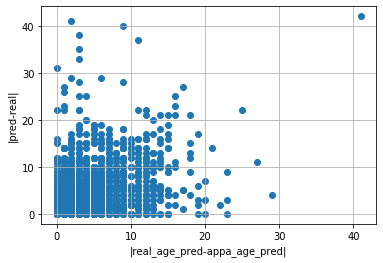

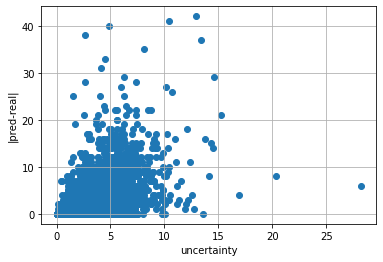

In [6]:
diff = np.abs(real_age_pred-appa_age_pred)
err = np.abs(real_age_pred-real_age)

c1= np.corrcoef(err,diff)
c2= np.corrcoef(err,real_age_pred_uncertain)

print("corrcoef(|real_pred-appa_pred|,err):", c1[0,1])
print("corrcoef(uncertainty,err):", c2[0,1])

plt.figure()
plt.scatter(diff,err)
plt.xlabel("|real_age_pred-appa_age_pred|")
plt.ylabel("|pred-real|")
plt.grid()

plt.figure()
plt.scatter(real_age_pred_uncertain,err)
plt.xlabel("uncertainty")
plt.ylabel("|pred-real|")
plt.grid()

## Real age prediction error distribution: machine versus human 

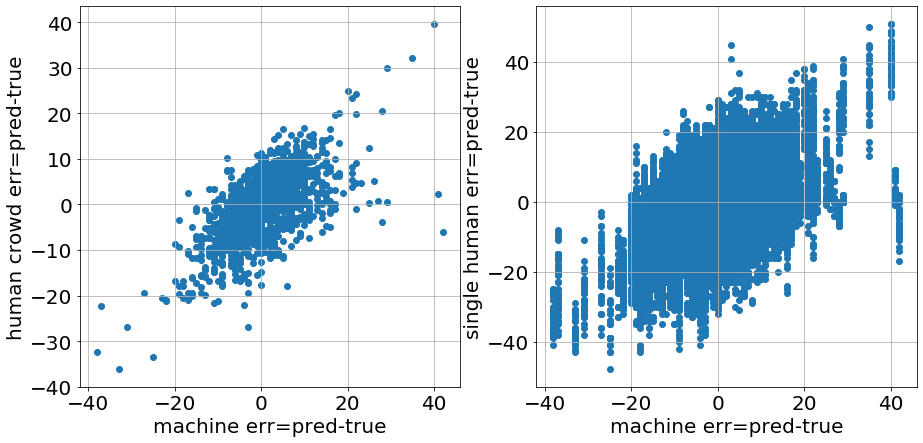

In [7]:
fig, axs = plt.subplots(1,2,figsize=(15,7))


#plt.figure(figsize=(8,8))
axs[0].scatter(real_age_pred_err,crowd_real_age_pred_err)
axs[0].set_xlabel('machine err=pred-true',fontsize=fontsize)
axs[0].set_ylabel('human crowd err=pred-true',fontsize=fontsize)
axs[0].grid(True)
#plt.xticks(fontsize=fontsize)
#plt.yticks(fontsize=fontsize)
axs[0].tick_params(axis='both',which='major',labelsize=fontsize)


#plt.figure(figsize=(8,8))
axs[1].scatter(real_age_pred_err_expanded,human_real_age_pred_err)
axs[1].set_xlabel('machine err=pred-true',fontsize=fontsize)
axs[1].set_ylabel('single human err=pred-true',fontsize=fontsize)
axs[1].grid(True)
#plt.xticks(fontsize=fontsize)
#plt.yticks(fontsize=fontsize)
axs[1].tick_params(axis='both',which='major',labelsize=fontsize)


## Show example faces with high/low prediction error

---------------------------------


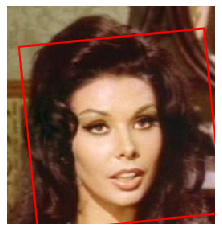

img path: 005638.jpg
img shape: (271, 259, 3)
bbox: [[ 14  50]
 [245  27]
 [268 257]
 [ 38 281]]
real age: 27
appa age: 29.7 (4.2)
machine real age: 29.0 (3.51)
machine appa age: 30.0 (3.98)
---------------------------------


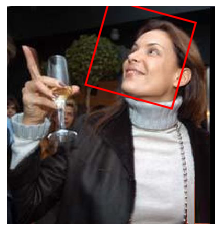

img path: 005640.jpg
img shape: (418, 398, 3)
bbox: [[196 -14]
 [362  31]
 [316 196]
 [150 150]]
real age: 38
appa age: 35.4 (6.0)
machine real age: 37.0 (5.3)
machine appa age: 32.0 (3.92)
---------------------------------


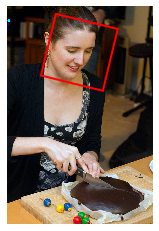

img path: 005641.jpg
img shape: (640, 427, 3)
bbox: [[143  22]
 [325  66]
 [281 248]
 [ 99 203]]
real age: 27
appa age: 23.9 (3.5)
machine real age: 22.0 (3.79)
machine appa age: 24.0 (2.62)
---------------------------------


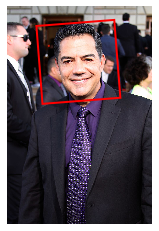

img path: 005642.jpg
img shape: (1500, 1000, 3)
bbox: [[201 135]
 [738  93]
 [780 630]
 [243 672]]
real age: 52
appa age: 47.2 (5.4)
machine real age: 54.0 (3.76)
machine appa age: 48.0 (4.26)
---------------------------------


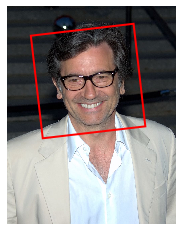

img path: 005643.jpg
img shape: (1293, 1000, 3)
bbox: [[140 174]
 [751 103]
 [821 713]
 [211 784]]
real age: 55
appa age: 54.1 (5.5)
machine real age: 57.0 (4.6)
machine appa age: 52.0 (4.65)
---------------------------------


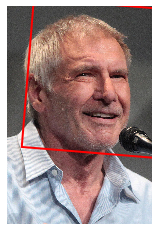

img path: 005644.jpg
img shape: (1501, 1000, 3)
bbox: [[ 184  -55]
 [1209   28]
 [1125 1054]
 [ 100  970]]
real age: 73
appa age: 63.8 (6.3)
machine real age: 66.0 (5.61)
machine appa age: 59.0 (4.01)
---------------------------------


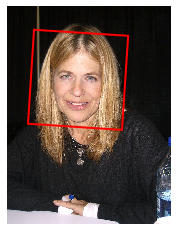

img path: 005645.jpg
img shape: (1333, 1000, 3)
bbox: [[164 143]
 [741 180]
 [703 757]
 [127 719]]
real age: 53
appa age: 47.3 (7.0)
machine real age: 56.0 (3.25)
machine appa age: 47.0 (3.34)
---------------------------------


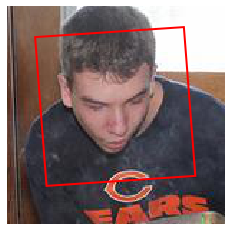

img path: 005646.jpg
img shape: (152, 152, 3)
bbox: [[ 19  21]
 [123  14]
 [131 118]
 [ 27 125]]
real age: 14
appa age: 16.4 (2.3)
machine real age: 16.0 (0.98)
machine appa age: 19.0 (2.03)
---------------------------------


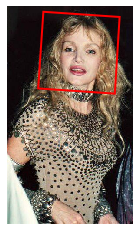

img path: 005648.jpg
img shape: (502, 290, 3)
bbox: [[ 83  12]
 [259  24]
 [248 201]
 [ 71 189]]
real age: 47
appa age: 40.4 (10.2)
machine real age: 44.0 (11.33)
machine appa age: 52.0 (5.4)
---------------------------------


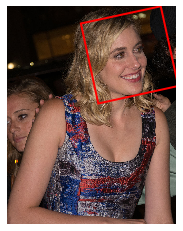

img path: 005649.jpg
img shape: (1288, 1000, 3)
bbox: [[ 436  101]
 [ 909   -1]
 [1013  471]
 [ 539  575]]
real age: 31
appa age: 27.8 (3.9)
machine real age: 29.0 (5.73)
machine appa age: 28.0 (1.3)
---------------------------------


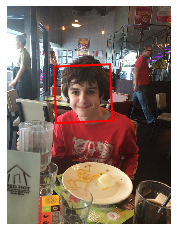

img path: 005650.jpg
img shape: (640, 480, 3)
bbox: [[137 177]
 [302 170]
 [309 336]
 [144 343]]
real age: 14
appa age: 10.6 (2.0)
machine real age: 12.0 (1.54)
machine appa age: 12.0 (2.14)
---------------------------------


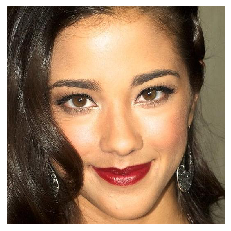

img path: 005651.jpg
img shape: (533, 533, 3)
bbox: [[-116  -69]
 [ 575 -145]
 [ 651  545]
 [ -39  622]]
real age: 21
appa age: 25.0 (2.8)
machine real age: 23.0 (4.9)
machine appa age: 22.0 (1.9)
---------------------------------


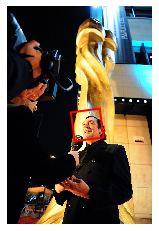

img path: 005652.jpg
img shape: (1503, 1000, 3)
bbox: [[440 733]
 [639 706]
 [666 905]
 [467 932]]
real age: 58
appa age: 51.4 (6.8)
machine real age: 60.0 (7.99)
machine appa age: 51.0 (5.9)
---------------------------------


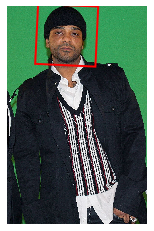

img path: 005653.jpg
img shape: (1557, 1000, 3)
bbox: [[221 -18]
 [651   1]
 [631 431]
 [200 411]]
real age: 32
appa age: 34.4 (5.0)
machine real age: 33.0 (5.24)
machine appa age: 32.0 (4.49)
---------------------------------


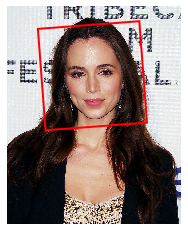

img path: 005654.jpg
img shape: (1250, 1000, 3)
bbox: [[176 129]
 [759  85]
 [803 668]
 [220 712]]
real age: 32
appa age: 30.9 (4.4)
machine real age: 28.0 (4.75)
machine appa age: 28.0 (2.04)
---------------------------------


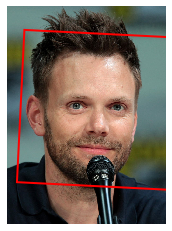

img path: 005655.jpg
img shape: (1371, 1000, 3)
bbox: [[ 108  148]
 [1068  196]
 [1021 1156]
 [  61 1108]]
real age: 43
appa age: 36.2 (4.6)
machine real age: 37.0 (5.53)
machine appa age: 35.0 (2.79)
---------------------------------


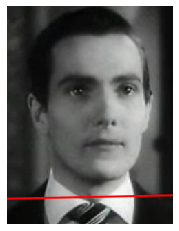

img path: 005656.jpg
img shape: (317, 241, 3)
bbox: [[-13 -15]
 [283 -22]
 [289 274]
 [ -7 280]]
real age: 28
appa age: 31.1 (5.6)
machine real age: 30.0 (3.66)
machine appa age: 27.0 (4.75)
---------------------------------


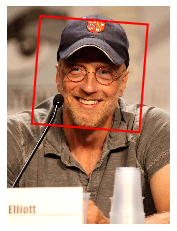

img path: 005658.jpg
img shape: (1337, 1000, 3)
bbox: [[203  59]
 [864 111]
 [812 773]
 [151 721]]
real age: 51
appa age: 52.1 (6.8)
machine real age: 53.0 (6.01)
machine appa age: 43.0 (5.44)
---------------------------------


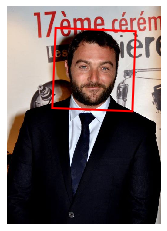

img path: 005659.jpg
img shape: (720, 508, 3)
bbox: [[160  71]
 [425  82]
 [414 347]
 [149 336]]
real age: 36
appa age: 38.4 (3.9)
machine real age: 35.0 (5.44)
machine appa age: 37.0 (3.58)
---------------------------------


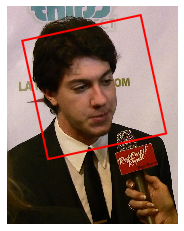

img path: 005660.jpg
img shape: (1058, 828, 3)
bbox: [[ 73 167]
 [649  42]
 [773 618]
 [198 743]]
real age: 23
appa age: 26.1 (3.5)
machine real age: 18.0 (2.2)
machine appa age: 20.0 (2.65)


In [8]:
#import cv2
import matplotlib.image as mpimg
import matplotlib.patches as patches

# large real age prediction error: small apparent age error
#indices = np.where( (np.abs(real_age_pred_err)>= 20) & (np.abs(crowd_real_age_pred_err) <= 10) )[0]

# large real age prediction error: large apparent age error
#indices = np.where( (np.abs(real_age_pred_err) >= 20) & (np.abs(crowd_real_age_pred_err) >= 20) )[0]

# small real age prediction error: large apparent age error
#indices = np.where( (np.abs(real_age_pred_err)<= 10) & (np.abs(crowd_real_age_pred_err) >= 20) )[0]
indices = np.where( (np.abs(real_age_pred_err)<= 10) & (np.abs(crowd_real_age_pred_err) <= 10) )[0]

# small real age prediction error: large signe human age error
#indices = np.where( (np.abs(real_age_pred_err)<= 10) & (np.abs(human_real_age_pred_mae) >= 20) )[0]

for i in indices[20:40]:
    print("---------------------------------")
    im = mpimg.imread( "/home/xfrancv/Data/Faces/APPA-REAL/test/"+img_path[i])
    fig, ax = plt.subplots()
    plt.imshow(im)
    plt.axis('off')
    rectangle = patches.Polygon(bbox[i], closed=True, linewidth=2, edgecolor='r', facecolor='none')

    ax.add_patch(rectangle)
    plt.show()

    print("img path:", img_path[i])
    print("img shape:", im.shape)
    print("bbox:",bbox[i])
    print("real age:", real_age[i])
    print(f"appa age: {appa_age[i]:.1f} ({appa_age_std[i]:.1f})")
    print(f"machine real age: {real_age_pred[i]} ({real_age_pred_uncertain[i]})")
    print(f"machine appa age: {appa_age_pred[i]} ({appa_age_pred_uncertain[i]})")


## Apparent age prediction by machine and human 

number of human guesses: 75464


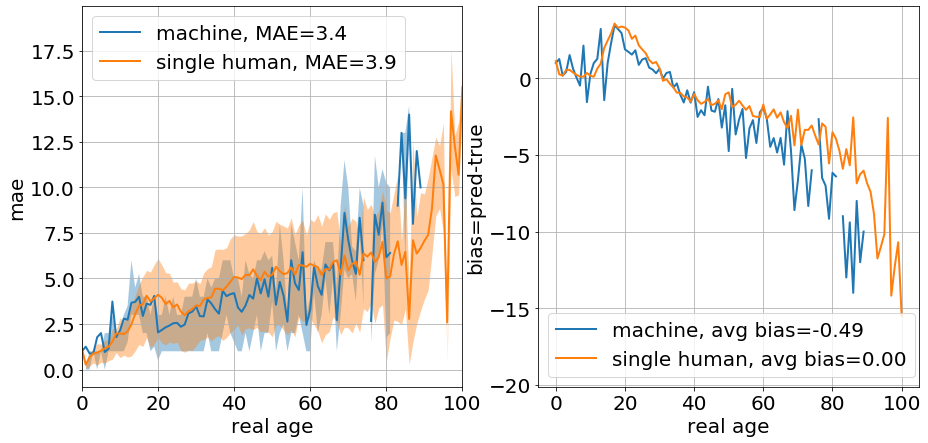

In [9]:
machine = read_machine_prediction(apparent=True)

age_range = [0,100]
machine_results = compute_errors(machine['age'],machine['age_pred'],age_range=age_range)

header, data = read_appareal_csv(['test'])
#header, data = read_appareal_csv(['test','train','valid'])
human = compute_crowd_estimate( data )
human_results = compute_errors(data['apparent_age'],human['apparent_age_expanded'],age_range=age_range)
print(f"number of human guesses: {len(data['apparent_age'])}")

#
fig, axs = plt.subplots(1,2,figsize=(15,7))

#
#plt.figure(figsize=(8,8))
h=axs[0].plot(machine_results['true_age'],machine_results['mae'],label=f"machine, MAE={machine_results['total_mae']:0.2}",linewidth=2)
axs[0].fill_between(machine_results['true_age'],machine_results['mae_low'],machine_results['mae_high'], alpha=0.4,linewidth=0,color=h[0].get_color())
h=axs[0].plot(human_results['true_age'],human_results['mae'],label=f"single human, MAE={human_results['total_mae']:0.2}",linewidth=2)
axs[0].fill_between(human_results['true_age'],human_results['mae_low'],human_results['mae_high'], alpha=0.4,linewidth=0,color=h[0].get_color())

axs[0].set_xlabel('real age',fontsize=fontsize)
axs[0].set_ylabel('mae',fontsize=fontsize)
axs[0].grid()
#axs[0].set_title(f"Apparent age prediction",fontsize=fontsize)
axs[0].legend(fontsize=fontsize)
#plt.xticks(fontsize=fontsize)
#plt.yticks(fontsize=fontsize)
axs[0].set_xlim(age_range[0],age_range[1])
axs[0].tick_params(axis='both',which='major',labelsize=fontsize)


#
#plt.figure(figsize=(8,8))
axs[1].plot(machine_results['true_age'],machine_results['bias'],label=f"machine, avg bias={machine_results['total_bias']:0.2f}",linewidth=2)
axs[1].plot(human_results['true_age'],human_results['bias'],label=f"single human, avg bias={human_results['total_bias']:0.2f}",linewidth=2)
axs[1].set_xlabel('real age',fontsize=fontsize)
axs[1].set_ylabel('bias=pred-true',fontsize=fontsize)
axs[1].grid()
#axs[1].set_title(f"Apparent age prediction",fontsize=fontsize)
axs[1].legend(fontsize=fontsize)
#axs[1].set_xticks(fontsize=fontsize)
#plt.yticks(fontsize=fontsize)
#plt.xlim(age_range[0],age_range[1])
axs[1].tick_params(axis='both',which='major',labelsize=fontsize)


## Real age prediction by humans and machines

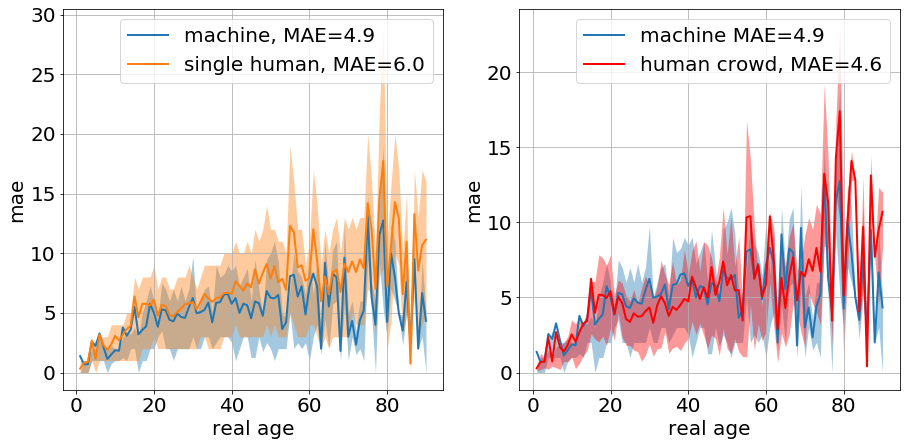

In [10]:
#header, data = read_appareal_csv(['train','test','valid'])
header, data = read_appareal_csv(['test'])

machine = read_machine_prediction(apparent=False)

crowd = compute_crowd_estimate( data )

age_range=[0,90]
human_results = compute_errors(data['real_age'],data['apparent_age'],age_range=age_range)
crowd_results = compute_errors(crowd['real_age'],crowd['apparent_age'],age_range=age_range)
machine_results = compute_errors(machine['age'],machine['age_pred'],age_range=age_range)

#
fig, axs = plt.subplots(1,2,figsize=(15,7))

#  human vs. machine
#plt.figure(figsize=(8,8))
h=axs[0].plot(machine_results['true_age'],machine_results['mae'],label=f"machine, MAE={machine_results['total_mae']:0.2}",linewidth=2)
axs[0].fill_between(machine_results['true_age'],machine_results['mae_low'],machine_results['mae_high'], alpha=0.4,linewidth=0,color=h[0].get_color())
h=axs[0].plot(human_results['true_age'],human_results['mae'],label=f"single human, MAE={human_results['total_mae']:0.2}",linewidth=2)
axs[0].fill_between(human_results['true_age'],human_results['mae_low'],human_results['mae_high'], alpha=0.4,linewidth=0,color=h[0].get_color())

axs[0].set_xlabel('real age',fontsize=fontsize)
axs[0].set_ylabel('mae',fontsize=fontsize)
axs[0].grid()
#axs[0].set_title(f"Real age prediction",fontsize=fontsize)
axs[0].legend(fontsize=fontsize)
#xs[0].xticks(fontsize=fontsize)
#plt.yticks(fontsize=fontsize)
#plt.xlim(age_range[0],age_range[1])
axs[0].tick_params(axis='both',which='major',labelsize=fontsize)

#  crowd vs. machine
#plt.figure(figsize=(8,8))
h=axs[1].plot(machine_results['true_age'],machine_results['mae'],label=f"machine MAE={machine_results['total_mae']:0.2}",linewidth=2)
axs[1].fill_between(machine_results['true_age'],machine_results['mae_low'],machine_results['mae_high'], alpha=0.4,linewidth=0,color=h[0].get_color())
h=axs[1].plot(crowd_results['true_age'],crowd_results['mae'],label=f"human crowd, MAE={crowd_results['total_mae']:0.2}",linewidth=2,color='r')
axs[1].fill_between(crowd_results['true_age'],crowd_results['mae_low'],crowd_results['mae_high'], alpha=0.4,linewidth=0,color=h[0].get_color())

axs[1].set_xlabel('real age',fontsize=fontsize)
axs[1].set_ylabel('mae',fontsize=fontsize)
axs[1].grid()
#axs[1].set_title(f"Real age prediction",fontsize=fontsize)
axs[1].legend(fontsize=fontsize)
#plt.xticks(fontsize=fontsize)
#plt.yticks(fontsize=fontsize)
#plt.xlim(age_range[0],age_range[1])
axs[1].tick_params(axis='both',which='major',labelsize=fontsize)


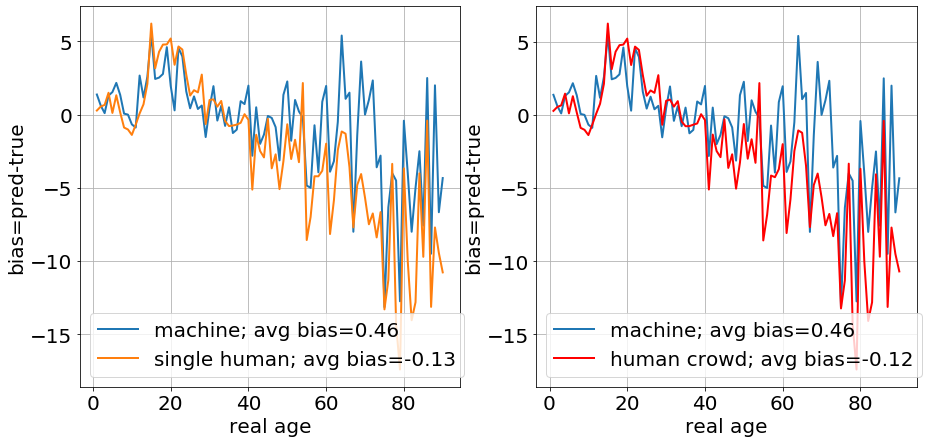

In [9]:
header, data = read_appareal_csv(['test'])
machine = read_machine_prediction(apparent=False)
crowd = compute_crowd_estimate( data )

age_range=[0,90]
human_results = compute_errors(data['real_age'],data['apparent_age'],age_range=age_range)
crowd_results = compute_errors(crowd['real_age'],crowd['apparent_age'],age_range=age_range)
machine_results = compute_errors(machine['age'],machine['age_pred'],age_range=age_range)

fig, axs = plt.subplots(1,2,figsize=(15,7))

#axs[0].figure(figsize=(8,8))
axs[0].plot(machine_results['true_age'],machine_results['bias'],label=f"machine; avg bias={machine_results['total_bias']:0.2f}",linewidth=2)
axs[0].plot(human_results['true_age'],human_results['bias'],label=f"single human; avg bias={human_results['total_bias']:0.2f}",linewidth=2)
#plt.plot(crowd_results['true_age'],crowd_results['bias'],'--',label=f"human crowd; avg bias={crowd_results['total_bias']:0.2f}",linewidth=2)
axs[0].set_xlabel('real age',fontsize=fontsize)
axs[0].set_ylabel('bias=pred-true',fontsize=fontsize)
axs[0].grid()
#axs[0]plt.title(f"Real age prediction",fontsize=fontsize)
axs[0].legend(fontsize=fontsize)
#plt.xticks(fontsize=fontsize)
#plt.yticks(fontsize=fontsize)
#plt.xlim(age_range[0],age_range[1])
axs[0].tick_params(axis='both',which='major',labelsize=fontsize)

#plt.figure(figsize=(8,8))
axs[1].plot(machine_results['true_age'],machine_results['bias'],label=f"machine; avg bias={machine_results['total_bias']:0.2f}",linewidth=2)
#plt.plot(human_results['true_age'],human_results['bias'],label=f"single human; avg bias={human_results['total_bias']:0.2f}",linewidth=2)
axs[1].plot(crowd_results['true_age'],crowd_results['bias'],color="r", label=f"human crowd; avg bias={crowd_results['total_bias']:0.2f}",linewidth=2)
axs[1].set_xlabel('real age',fontsize=fontsize)
axs[1].set_ylabel('bias=pred-true',fontsize=fontsize)
axs[1].grid()
#plt.title(f"Real age prediction",fontsize=fontsize)
axs[1].legend(fontsize=fontsize)
axs[1].tick_params(axis='both',which='major',labelsize=fontsize)
#plt.xticks(fontsize=fontsize)
#plt.yticks(fontsize=fontsize)
#plt.xlim(age_range[0],age_range[1])


## Statistics of the database



### Distribution of worker age and gender

This is not the true distribution of the worker age/gender because the work's ID are not in the database. The distributions would be correct provided each worker made the same number of guesses.

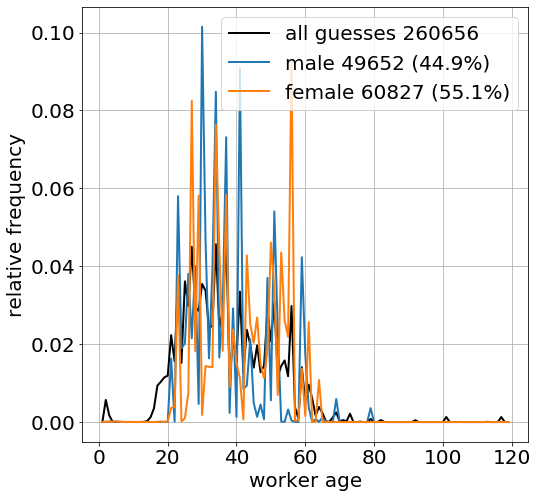

In [11]:
fig, axs = plt.subplots(1,1,figsize=(8,8))

#plt.figure(figsize=(8,8))
header, data = read_appareal_csv(['train','test','valid'])

n_guesses = len(data['worker_age'])
hist, edges = np.histogram(data['worker_age'], bins=range(0,120),density=True)  # You can adjust the number of bins
axs.plot(edges[1:],hist,label=f"all guesses {n_guesses}",linewidth=2,color='k')

male_indices = np.where( data['worker_gender']=="m" )[0]
n_male_guesses = len(data['worker_age'][male_indices])
female_indices = np.where( data['worker_gender']=="f" )[0]
n_female_guesses = len(data['worker_age'][female_indices])

hist, edges = np.histogram(data['worker_age'][male_indices], bins=range(0,120),density=True)  # You can adjust the number of bins
axs.plot(edges[1:],hist,label=f"male {n_male_guesses} ({100*n_male_guesses/(n_male_guesses+n_female_guesses):.1f}%)",linewidth=2)

hist, edges = np.histogram(data['worker_age'][female_indices], bins=range(0,120),density=True)  # You can adjust the number of bins
axs.plot(edges[1:],hist,label=f"female {n_female_guesses} ({100*n_female_guesses/(n_male_guesses+n_female_guesses):.1f}%)",linewidth=2)

#plt.xticks(fontsize=fontsize)
#plt.yticks(fontsize=fontsize)
axs.tick_params(axis='y',labelsize=fontsize)
axs.tick_params(axis='x',labelsize=fontsize)
#plt.title("Workers' distribution",fontsize=fontsize)
axs.set_xlabel("worker age",fontsize=fontsize)
axs.set_ylabel("relative frequency",fontsize=fontsize)
axs.legend(fontsize=fontsize)
axs.grid(True)


### Distribution of the number of guesses per image

No handles with labels found to put in legend.


file width the maximal number of 609 guesses: ['005035.jpg'] (index=[5035])
avg # of guesses: 34.3375049400606
median # of guesses: 37.0
face with the maximal number of 609 guesses: ['005035.jpg'] (index=[5035])


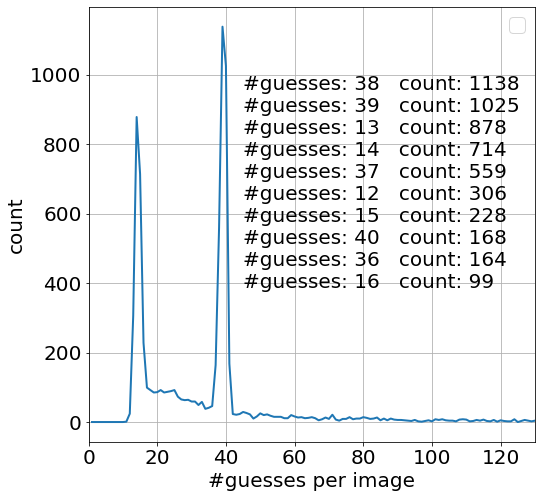

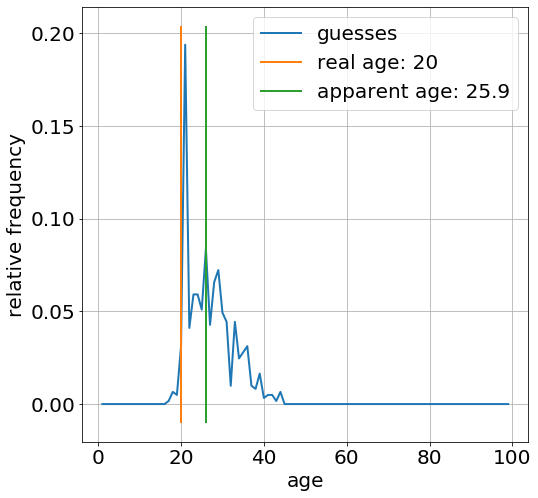

In [16]:

## distirbution of guesses
fig, axs = plt.subplots(1,1,figsize=(8,8))
grouped_data = compute_crowd_estimate( data )
max_n_guesses = np.max(grouped_data['num_guesses'])
hist, edges = np.histogram(grouped_data['num_guesses'], bins=range(0,max_n_guesses+1),density=False)  

ind = np.where(grouped_data['num_guesses']==max_n_guesses)[0]
print(f"file width the maximal number of {max_n_guesses} guesses: {grouped_data['file_name'][ind]} (index={ind})")
print("avg # of guesses:", np.mean(grouped_data['num_guesses']) )
print("median # of guesses:", np.median(grouped_data['num_guesses']) )

ind = np.argsort(-hist)
text = ""
for i in ind[:10]:
    text += f"#guesses: {i}   count: {np.sum(grouped_data['num_guesses']==i)}\n" 


axs.set_xlim(0,130)
axs.plot(edges[1:],hist,linewidth=2)
#plt.xticks(fontsize=fontsize)
#plt.yticks(fontsize=fontsize)
axs.tick_params(axis='y',labelsize=fontsize)
axs.tick_params(axis='x',labelsize=fontsize)
axs.set_xlabel("#guesses per image",fontsize=fontsize)
axs.set_ylabel("count",fontsize=fontsize)
axs.legend(fontsize=fontsize)
#ax1].set_xticks(np.linspace(0,1,100))
axs.grid(True)
axs.text(45, 1000, text, ha='left', va='top', fontsize=fontsize)


## distribution of guesses for the face image with the maximal number of guesses
# the image probably appeared as the first one on ageguess.org
max_n_guesses = np.max(grouped_data['num_guesses'])
ind = np.where(grouped_data['num_guesses']==max_n_guesses)[0]

real_age = grouped_data['real_age'][ind[0]]
apparent_age = grouped_data['apparent_age'][ind[0]]
hist, edges = np.histogram(grouped_data['guesses'][ind[0]], bins=range(0,100),density=True)  

print(f"face with the maximal number of {max_n_guesses} guesses: {grouped_data['file_name'][ind]} (index={ind})")

plt.figure(figsize=(8,8))
plt.plot(edges[1:],hist,linewidth=2,label="guesses")
plt.xlabel("age",fontsize=fontsize)
plt.ylabel("relative frequency",fontsize=fontsize)
ymin, ymax = plt.gca().get_ylim()
plt.plot([real_age,real_age],[ymin,ymax],label=f"real age: {real_age:.0f}",linewidth=2)
plt.plot([apparent_age,apparent_age],[ymin,ymax],label=f"apparent age: {apparent_age:0.1f}",linewidth=2)
plt.grid()
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.legend(fontsize=fontsize)

### Real/apparent age distribution in the image database 

real age range: 1 - 100
age guess range: 0 - 100


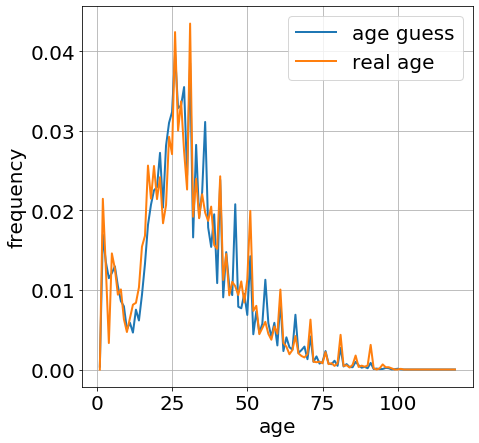

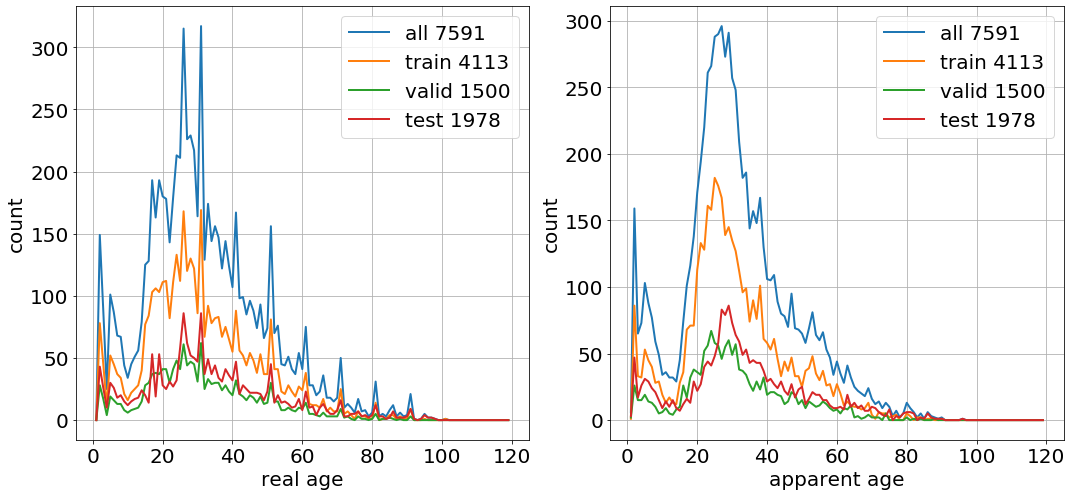

In [5]:
header, data = read_appareal_csv(['train','test','valid'])

print("real age range:",np.min(data['real_age']),"-",np.max(data['real_age']))
print("age guess range:",np.min(data['apparent_age']),"-",np.max(data['apparent_age']))

fig, axs = plt.subplots(1,1,figsize=(7,7))
hist, edges = np.histogram(data['apparent_age'], bins=range(0,120),density=True)  # You can adjust the number of bins
axs.plot(edges[1:],hist,label="age guess",linewidth=2)
hist, edges = np.histogram(data['real_age'], bins=range(0,120),density=True)  # You can adjust the number of bins
axs.plot(edges[1:],hist,label="real age",linewidth=2)
axs.tick_params(axis='x',labelsize=fontsize)    
axs.tick_params(axis='y',labelsize=fontsize)
axs.set_xlabel("age",fontsize=fontsize)
axs.set_ylabel("frequency",fontsize=fontsize)
axs.grid(True)
axs.legend(fontsize=fontsize)

#
fig, axs = plt.subplots(1,2,figsize=(15,7))

for i, age in enumerate(['real_age','apparent_age']):
    #axs[i].set_title(f"{age}",fontsize=fontsize)
    for subset in [['train','test','valid'],'train','valid','test']:
        header, data = read_appareal_csv(subset)
        grouped_data = compute_crowd_estimate( data )

        n = len(grouped_data[age])
        hist, edges = np.histogram(grouped_data[age], bins=range(0,120),density=False)  # You can adjust the number of bins
        label = f"all {n}" if isinstance(subset,list) else f"{subset} {n}"
        axs[i].plot(edges[1:],hist,label=label,linewidth=2)
        axs[i].set_xlabel(age.replace('_',' '),fontsize=fontsize)
        axs[i].set_ylabel("count",fontsize=fontsize)
        axs[i].legend(fontsize=fontsize)
        axs[i].grid(True)
        axs[i].tick_params(axis='x',labelsize=fontsize)    
        axs[i].tick_params(axis='y',labelsize=fontsize)
        plt.tight_layout()

In [14]:
#header, data = read_appareal_csv(['test'])
header, data = read_appareal_csv(['test','train','valid'])
#grouped_data = compute_crowd_estimate( data )

#def print_frequencies(sequence ):
#seq = data['apparent_age']
def print_frequences(seq):
    n_even = np.sum( seq % 2 == 0)
    n_odd = np.sum( seq % 2 != 0)
    n = len( seq)
    print("even:", f"{n_even/n:.2f}")
    print("odd:", f"{n_odd/n:.2f}")

    for div in [3,4,5,6,7,8,9,10]:
        n_div = np.sum( seq % div == 0)
        print("div:", f"{div:2}", " 1/div:", f"{1/div:.2f}", " freq:", f"{n_div/n:.2f}")


print("REAL AGE:")
print_frequences(data['real_age'][ind]) 

print()
print("APPARENT AGE:")
print_frequences(data['apparent_age'][ind]) 

REAL AGE:
even: 0.50
odd: 0.50
div:  3  1/div: 0.33  freq: 0.29
div:  4  1/div: 0.25  freq: 0.25
div:  5  1/div: 0.20  freq: 0.21
div:  6  1/div: 0.17  freq: 0.16
div:  7  1/div: 0.14  freq: 0.12
div:  8  1/div: 0.12  freq: 0.12
div:  9  1/div: 0.11  freq: 0.10
div: 10  1/div: 0.10  freq: 0.09

APPARENT AGE:
even: 0.48
odd: 0.52
div:  3  1/div: 0.33  freq: 0.30
div:  4  1/div: 0.25  freq: 0.26
div:  5  1/div: 0.20  freq: 0.24
div:  6  1/div: 0.17  freq: 0.18
div:  7  1/div: 0.14  freq: 0.09
div:  8  1/div: 0.12  freq: 0.14
div:  9  1/div: 0.11  freq: 0.07
div: 10  1/div: 0.10  freq: 0.08


## Average apparent vs. real age

In [16]:
def real_vs_apparent( data, worker_age_range, worker_gender=None ):
    real = np.arange(0, 101)
    apparent = np.full(real.size,np.nan)
    apparent_low = np.full(real.size, np.nan)
    apparent_high = np.full(real.size, np.nan)
    mae = 0.0
    n = 0
    for i, a in enumerate(real):

        # filter out guesses 
        filter = data['real_age'] == a
        filter &= (data['worker_age'] >= worker_age_range[0]) & (data['worker_age']<= worker_age_range[1])
        if worker_gender is not None:
            filter &=  data['worker_gender'] == worker_gender

        indices = np.where( filter )[0]
        
        if len(indices) > 0:
            n += len(indices)
            mae += np.nansum( np.abs( a - data['apparent_age'][indices]) )
            apparent[i] = np.nanmean(data['apparent_age'][indices])
            apparent_low[i] = np.percentile(data['apparent_age'][indices], 25)
            apparent_high[i] = np.percentile(data['apparent_age'][indices], 75)

    mae = mae / n
    filtered = ~np.isnan(apparent)
    return real[filtered], apparent[filtered], apparent_low[filtered], apparent_high[filtered], n, mae


def make_figure(figsize,title,axs=None):
    if axs is None:
        axs = plt.gca()
        
    #axs.figure(figsize=figsize)    
    #axs.title(title,fontsize=fontsize)
    axs.plot([0,100],[0,100],color='black',linestyle='--',linewidth=2)
    axs.set_xlabel('real age',fontsize=fontsize)
    axs.set_ylabel('average apparent age',fontsize=fontsize)
    axs.grid()
    #axs.set_xticks(fontsize=fontsize)
    #axs.yticks(fontsize=fontsize)
    axs.set_xticks(np.linspace(0,100,11))
    axs.set_yticks(np.linspace(0,100,11))
    axs.tick_params(axis='both',which='major',labelsize=fontsize)


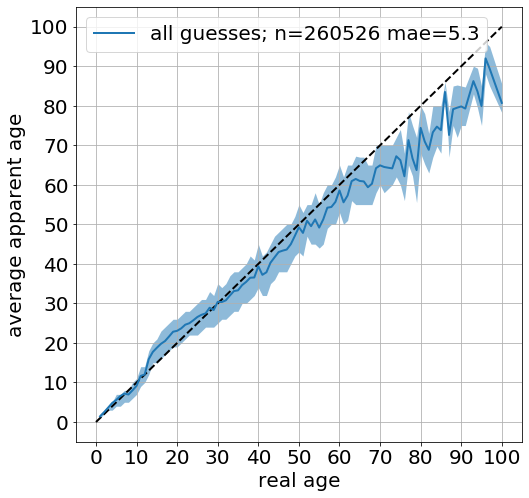

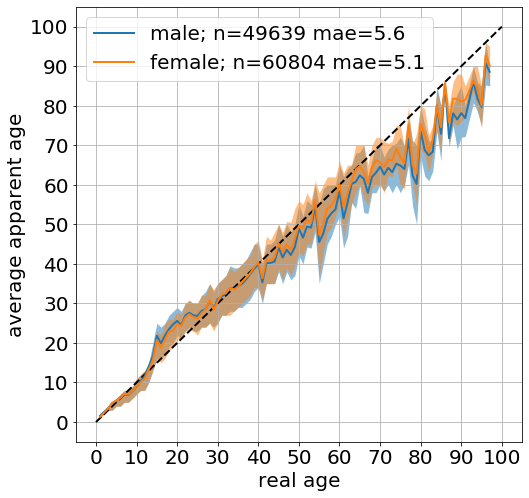

In [17]:
header, data = read_appareal_csv(["train","valid","test"])
#header, data = read_appareal_csv(["test"])

fig, axs = plt.subplots(1,1,figsize=(8,8))

# appa vs real for worker age groups
make_figure(figsize=(8,8),title="apparent vs. real age",axs=axs)
real, apparent, apparent_low, apparent_high, n, mae = real_vs_apparent( data, worker_age_range=[-1000,1000] )
h=axs.plot(real,apparent,linewidth=2,label=f'all guesses; n={n} mae={mae:0.1f}')
axs.fill_between(real,apparent_low,apparent_high, alpha=0.5,linewidth=0,color=h[0].get_color())
axs.legend(fontsize=fontsize)

# for each gender separately
fig, axs = plt.subplots(1,1,figsize=(8,8))
make_figure(figsize=(8,8),title="apparent vs. real age given worker's gender",axs=axs)
real, apparent,apparent_low,apparent_high, n, mae = real_vs_apparent( data, worker_age_range=[0,100], worker_gender='m' )
h=axs.plot(real,apparent,linewidth=2,label=f"male; n={n} mae={mae:0.1f}")
axs.fill_between(real,apparent_low,apparent_high, alpha=0.5,linewidth=0,color=h[0].get_color())

real, apparent,apparent_low,apparent_high, n, mae = real_vs_apparent( data, worker_age_range=[0,100], worker_gender='f' )
h=axs.plot(real,apparent,linewidth=2,label=f"female; n={n} mae={mae:0.1f}")
axs.fill_between(real,apparent_low,apparent_high, alpha=0.5,linewidth=0,color=h[0].get_color())
axs.legend(fontsize=fontsize)

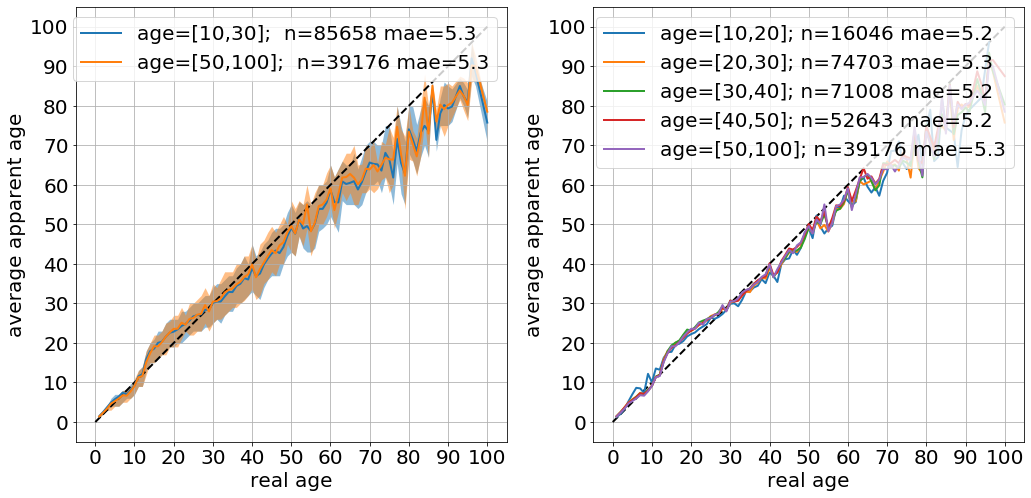

In [22]:

fig, axs = plt.subplots(1,2,figsize=(17,8))

# appa vs real for worker age groups
make_figure(figsize=(9,9),title="apparent vs. real age given worker's age",axs=axs[0])
#for low,hi in zip([10,20,30,40,50],[20,30,40,50,100]):
for low,hi in zip([10,50],[30,100]):
    real, apparent, apparent_low, apparent_high, n, mae = real_vs_apparent( data, worker_age_range=[low,hi] )
    h=axs[0].plot(real,apparent,linewidth=2,label=f"age=[{low},{hi}];  n={n} mae={mae:0.1f}")
    axs[0].fill_between(real,apparent_low,apparent_high, alpha=0.5,linewidth=0,color=h[0].get_color())
axs[0].legend(fontsize=fontsize)

#
make_figure(figsize=(9,9),title="apparent vs. real age given worker's age",axs=axs[1])
for low,hi in zip([10,20,30,40,50],[20,30,40,50,100]):
    real, apparent, apparent_low, apparent_high,n, mae = real_vs_apparent( data, worker_age_range=[low,hi] )
    n_workers = ((data['worker_age']>=low) & (data['worker_age']<=hi )).sum()
    h=axs[1].plot(real,apparent,linewidth=2,label=f"age=[{low},{hi}]; n={n} mae={mae:.1f}")
axs[1].legend(fontsize=fontsize)



In [49]:
def coverage_vs_interval_size(arr,):

    # compute occurences of the elemens in arr
    unique_elements, counts = np.unique(arr, return_counts=True)
    max_element = np.max(unique_elements)
    occurrences = np.zeros(max_element + 1, dtype=int)
    occurrences[unique_elements] = counts

    # 
    cum_sum = np.cumsum(occurrences)

    n = len(cum_sum)
    coverage = np.zeros(n)
    for i in range(n):
        coverage[i] = np.max( np.insert(cum_sum[i+1:] - cum_sum[0:-(i+1)], 0, cum_sum[i]) )

    coverage = coverage / np.sum(occurrences)

    return coverage, occurrences

# 
#arr = np.array([1, 2, 3, 4, 1, 2, 1, 3, 4, 5,0,0,0,5])
#arr = image_data['guesses'][0]
#coverage, occurrences = coverage_vs_interval_size(arr)
#print("array:", arr)
#print("occurrences:", occurrences)
#print("coverage:", coverage)


#
header, data = read_appareal_csv(['test'])
image_data = compute_crowd_estimate( data )

n_images = len(image_data['guesses'])
max_age = np.max( [np.max(array) for array in image_data['guesses'] ] )

coverage = np.ones((max_age+1,n_images))
for i in range(n_images):
    guesses = image_data['guesses'][i]
    coverage_of_ith_image, _ = coverage_vs_interval_size(guesses)    
    coverage[:len(coverage_of_ith_image),i] = coverage_of_ith_image



cov=0.5 age=5 avg_width=[2.19230769]
cov=0.5 age=10 avg_width=[2.93333333]
cov=0.5 age=15 avg_width=[5.]
cov=0.9 age=5 avg_width=[4.57692308]
cov=0.9 age=10 avg_width=[7.8]
cov=0.9 age=15 avg_width=[12.35714286]
cov=0.95 age=5 avg_width=[5.23076923]
cov=0.95 age=10 avg_width=[8.8]
cov=0.95 age=15 avg_width=[14.07142857]


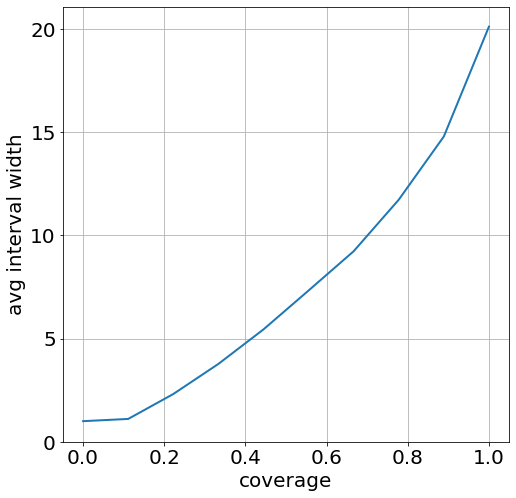

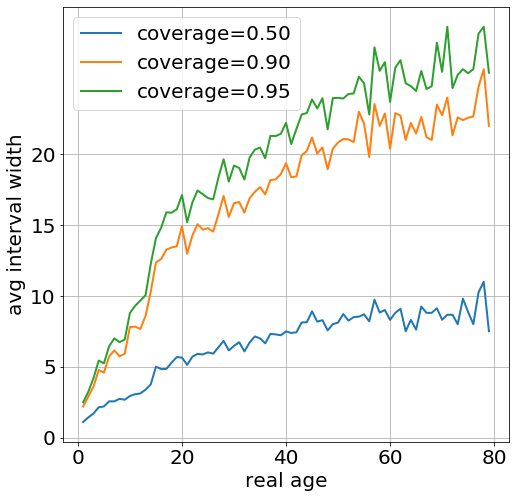

In [51]:

fig, axs = plt.subplots(1,1,figsize=(8,8))

coverage_range = np.linspace(0,1,10)
avg_interval_width = []
for desired_coverage in coverage_range:
    interval_widths = np.argmax(coverage>=desired_coverage,axis=0)
    avg_interval_width.append(np.mean(interval_widths)+1)

axs.plot(coverage_range,avg_interval_width,linewidth=2)
axs.grid(True)
axs.set_xlabel('coverage',fontsize=fontsize)
axs.set_ylabel('avg interval width',fontsize=fontsize)
#plt.xticks(fontsize=fontsize)
#plt.yticks(fontsize=fontsize)
axs.set_xticks(np.linspace(0,1,6))
axs.set_yticks(np.linspace(0,20,5))
axs.tick_params(axis='both',which='major',labelsize=fontsize)


fig, axs = plt.subplots(1,1,figsize=(8,8))

for desired_coverage in [0.5,0.9,0.95]:
    age_range = np.arange(0,80)
    avg_interval_width = []
    for age in age_range:
        indices = np.where(image_data['real_age']==age)[0]
        interval_widths = np.argmax(coverage[:,indices] >= desired_coverage,axis=0)
        if len(interval_widths) > 0:
            avg_interval_width.append(np.mean(interval_widths)+1)
        else:
            avg_interval_width.append(np.nan)

    avg_interval_width = np.array( avg_interval_width)
    filtered = ~np.isnan(avg_interval_width)  
    axs.plot(age_range[filtered],avg_interval_width[filtered],linewidth=2,label=f"coverage={desired_coverage:0.2f}")

    for age in [5,10,15]:
        ind = np.where(age_range==age)[0]
        print(f"cov={desired_coverage} age={age} avg_width={avg_interval_width[ind]}")


axs.grid(True)
axs.set_xlabel('real age',fontsize=fontsize)
axs.set_ylabel('avg interval width',fontsize=fontsize)
#plt.xticks(fontsize=fontsize)
#plt.yticks(fontsize=fontsize)
#axs[1].set_xticks(np.linspace(0,1,5))
axs.set_yticks(np.linspace(0,20,5))
axs.legend(fontsize=fontsize)
axs.tick_params(axis='both',which='major',labelsize=fontsize)
